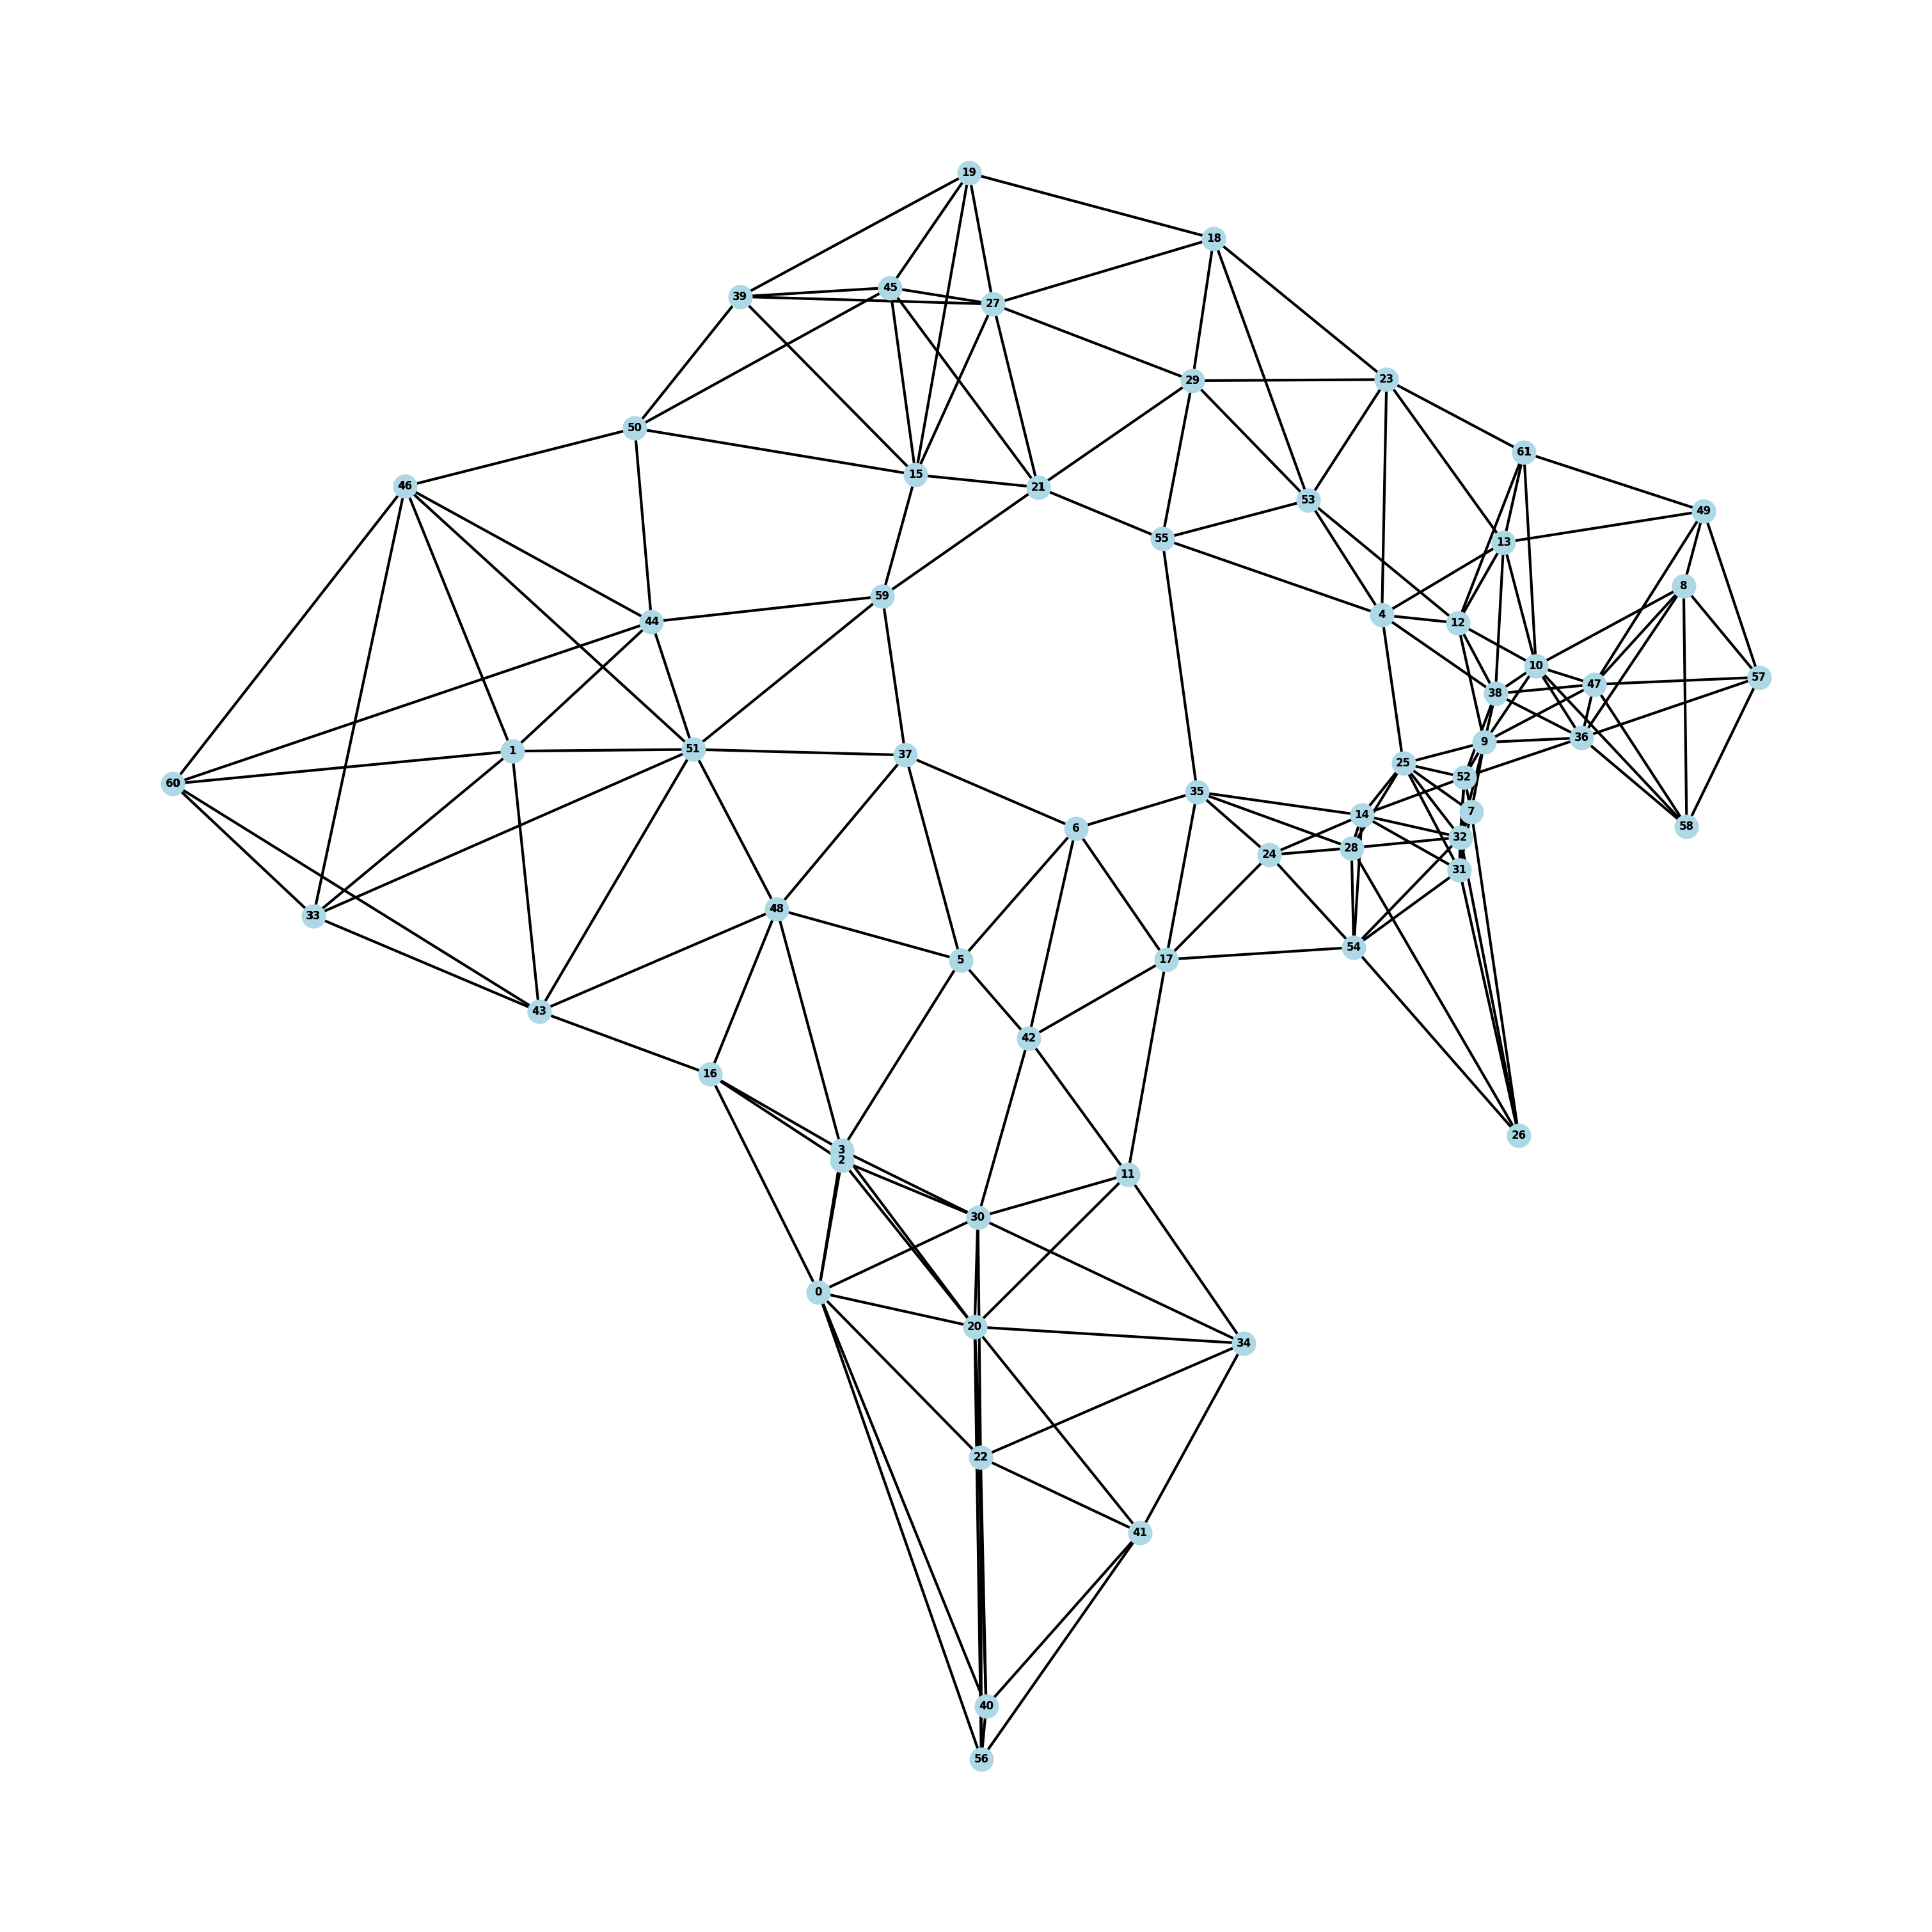

In [1]:
import torch
import sys
import itertools
import os
import copy
import json
import time
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import xarray as xr

from torch_geometric.nn.conv import GCNConv, ChebConv
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler
sys.path.append("../src")
from pathlib import Path
from Models.model import GLSTM_v2, GraphTemporalTransformer_v1
from Data.file_utils import create_next_experiment_folder
from Models.models_utils import reset_weights
from Data.prepare_data import *
from Data.preprocessing import (normalize_tp, 
                                normalize_features, 
                                assert_finite,
                                fit_log1p_zscore_stats,
                                apply_log1p_zscore,
                                add_consecutive_dry_days_feature)
                                
from Data.feature_extraction import (daily_vertical_velocity, 
                                     get_vv, daily_temp_features, 
                                     get_temp, 
                                     daily_wind_uv_features,
                                     era5_uv_to_tensor,
                                     station_dictionary,
                                     #haversine_km,
                                     tensor_data_precip,
                                     era5_specific_humidity_tensor,
                                     forecast_steps_to_daily_precip,
                                     era5_daily_precip_all,
                                     daily_precip_dataset_to_tensor,
                                     get_wind_uv
                                     )     
          
from Evaluation.metrics import safe_r2, safe_mape, combined_loss, weighted_mse_loss, make_weighted_mse_loss_standardized
from Evaluation.comparison_plots import save_error_plots, plot_heatmap_nn, model_weights_hist, plot_heatmap_nn, scatter_true_pred
from Graph.graph_related_utils import adjacency_matrix, knn_topology, plot_graph, graph_matrix_index, distance_graph
from Training.Training_Routines import train_stable


device = "cuda" if torch.cuda.is_available() else "cpu"

if torch.cuda.is_available():
    torch.set_float32_matmul_precision('high')
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

RUN_MODE        = "quick"                 # quick or full
if RUN_MODE     == "full":
    start_date  = "2000-01-01"
    end_date    = "2025-12-31"

elif RUN_MODE   == "custom":
    start_date  = "2010-01-01"
    end_date    = "2025-12-31"

else:
    start_date = "2024-01-01"
    end_date   = "2025-12-31"

T            = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 1

eps          = 1e-6
window_size  = 30
horizon      = 1
criterion_km = 120
lstm_layers  = 1
dropout      = 0.2
K            = 5
batch_size   = 256
num_workers  = 4
vertex_idx   = 32
weight_decay = 5e-4
T_max        = 50
test_lstm    = False
learn_adj    = True
criterion    = nn.HuberLoss(delta=5)
topology     = 'knn'  # 'knn' ou 'distance'

log_norm     = False 
z_score      = True


catalog_dir = Path(os.path.join("..", "Datasets", "dados_inmet"))
catalog_file = list(catalog_dir.glob("Catalogo*.csv"))[0]
catalogo_inmet = pd.read_csv(catalog_file, sep=';')
estacoes_RS = station_dictionary(catalogo_inmet)



N = len(estacoes_RS)
if topology =='knn':
    edge_index, pos               = knn_topology(estacoes_RS, k=K)
else:
    edge_index, edge_weights, pos = distance_graph(estacoes_RS, criterion_km)
    
    
    
plot_graph(N,edge_index, pos=pos)

In [2]:
# Carregamento dos arquivos NetCDF (Datasets)
dataset_load_time = time.time()
rea_tp   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_precipitation_80-26.nc")).sel(time=slice(start_date, end_date))
#rea_vv   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "vv_94-25.nc")).sel(time=slice(start_date, end_date))
rea_temp = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "temp_99-25.nc")).sel(time=slice(start_date, end_date))
rea_sh   = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_sh_00-25.nc")).sel(time=slice(start_date, end_date))
#rea_wind = xr.open_dataset(os.path.join("..", "Datasets", "nc_files", "era5_wind_14-25.nc")).sel(time=slice(start_date, end_date))
print("Done loading datasets in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time  = time.time()
#vv_daily_dataset   = daily_vertical_velocity(rea_vv, var_name="w")
#print("Done loading vv in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time  = time.time()
temp_daily_dataset = daily_temp_features(rea_temp)
print("Done loading temp in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time  = time.time()
tp_daily_dataset   = forecast_steps_to_daily_precip(rea_tp, to_mm=True).isel(time=slice(None, -1))
print("Done loading tp in memory"+"\nTime taken: {:.2f} seconds".format(time.time() - dataset_load_time))
dataset_load_time = time.time()
#wind_daily = daily_wind_uv_features(rea_wind)
#print("Done loading wind in memory"+"\nTime taken: {:.2f} seconds".format(time.time()-dataset_load_time))

print("Dataset com", temp_daily_dataset.time.values.shape[0], "dias disponíveis.")

Done loading datasets in memory
Time taken: 1.78 seconds
Done loading temp in memory
Time taken: 0.69 seconds
Done loading tp in memory
Time taken: 0.87 seconds
Dataset com 731 dias disponíveis.


# Extração do dataset do ERA-5





Input features
 - Daily precipitation
 - vertical velocity of wind
 - Temperature and dewpoint
 - u-v components of wind

The tensor $X$ has shape $[days, nodes, features]$, with all dataset available, with the $X$ we construct the time windows $X_s$ (inputs) and $y_s$ (targets)



In [3]:
X_tp = daily_precip_dataset_to_tensor(tp_daily_dataset, stations=estacoes_RS).reshape(T, N, 1)

X_year = torch.tensor(
    [[np.sin(np.pi * (t % 365 + 1) / 365) for _ in range(N)] for t in range(T)],
    dtype=torch.float32,
).reshape(T, N, 1)

X_temp = get_temp(start_date, end_date, temp_daily_dataset, estacoes_RS)

#X_vv = get_vv(start_date, end_date, vv_daily_dataset, estacoes_RS)

X_sh = era5_specific_humidity_tensor(os.path.join("..", "Datasets", "nc_files", "era5_sh_00-25.nc"), estacoes_RS, start=start_date, end=end_date, var_name="q")


#X_wind = era5_uv_to_tensor(r"C:\Climate Change Project\Utils\wind_data\era5_wind_14-25.nc",
#                           estacoes_RS,
#                           start=start_date,
#                           end=end_date,
#                           u_var="u",
#                           v_var="v"
#                           ).reshape(X_tp.shape[0], X_tp.shape[1], -1)

# Creating temporal dataset

The tensor X is transformed in two new tensors, $X_s$ and $y_s$ (inputs and targets), such that: 

 - $X_s$: $[B, W_{in}, N, F]$;
 - $y_s$: $[B, W_{out}, N]$;
 - $B$ : number of time windows created, with $W_{in}$ days of feed to forecast the next $W_{out}$ days;
 - $N$  : number of nodes (stations)
 - $F$  : number of input features by node



In [4]:
#CRIAÇÃO DE JANELAS DE TEMPO

# Escolha das features para alimentar o modelo
X = torch.cat([X_tp, X_temp, X_sh], dim=-1)

if log_norm:
    X[...,0] = torch.log1p(X[...,0])


#X = add_consecutive_dry_days_feature(
#    X, 
#    precip_col=0,
#    dry_threshold=2
#)


print(X.shape)



print("Janela de entrada: "+str(window_size)+" dias, horizonte de previsão: "+str(horizon)+" dias")
X_train, y_train, X_val, y_val, X_test, y_test = temporal_train_val_test_split(X, X[...,0], window_size=window_size, horizon=horizon)


# Cria janelas de treino, validação e teste
# = train_split(Xs, ys)

if z_score:
    scaler_tp = StandardScaler()
    scaler_tp.fit(X_train[...,0].reshape(-1,1))
    X_train[...,0]  = torch.tensor(scaler_tp.transform(X_train[...,0].reshape(-1,1)), dtype=torch.float32).reshape(X_train[...,0].shape)
    y_train         = torch.tensor(scaler_tp.transform(y_train.reshape(-1,1)), dtype=torch.float32).reshape(y_train.shape)
    X_val[...,0]    = torch.tensor(scaler_tp.transform(X_val[...,0].reshape(-1,1)  ), dtype=torch.float32).reshape(X_val[...,0].shape)
    y_val           = torch.tensor(scaler_tp.transform(y_val.reshape(-1,1)), dtype=torch.float32).reshape(y_val.shape)
    X_test[...,0]   = torch.tensor(scaler_tp.transform(X_test[...,0].reshape(-1,1)  ), dtype=torch.float32).reshape(X_test[...,0].shape)


# padroniza apenas features exogenas (colunas 2:)
X_train[..., 1:], scalers = normalize_features(X_train[..., 1:], scaler=MinMaxScaler)

for i, sc in enumerate(scalers):
    X_val[..., 1 + i] = torch.tensor(
        sc.transform(X_val[..., 1 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_val[..., 1 + i].shape)
    X_test[..., 1 + i] = torch.tensor(
        sc.transform(X_test[..., 1 + i].reshape(-1, 1)), dtype=torch.float32
    ).reshape(X_test[..., 1 + i].shape)

# Train/val split and DataLoaders
train_loader, val_loader, test_loader = create_batchs(X_train, X_val, X_test, y_train, y_val, y_test, batch_size, device=device, num_workers=num_workers, persistent_workers=True, prefetch_factor=4)
print("train batches:", len(train_loader), "val batches:", len(val_loader), "test batches:", len(test_loader))

torch.Size([731, 62, 13])
Janela de entrada: 30 dias, horizonte de previsão: 1 dias
train batches: 2 val batches: 1 test batches: 1


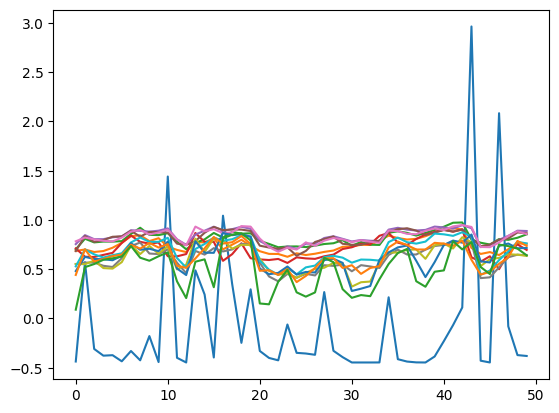

In [5]:
for i in range(X_train.shape[-1]):
    plt.plot(X_train[:T_max,0,vertex_idx,i].flatten(), label=f'Feature {i}')
    #plt.legend()

# Training


In [8]:
lr_v                = [1e-2]
weight_decay_v      = [1e-3]
hidden_dim_v        = [32,64,128]
dropout_v           = [0.1]
delta_h             = 5.0
criterion           = make_weighted_mse_loss_standardized(y_train,
                                                          extreme_quantile=0.7,
                                                          extreme_weight=10.0,
                                                          normalize_weights=True)

empty_graph         = torch.zeros((edge_index.shape))

combinations        = list(itertools.product(lr_v, weight_decay_v, hidden_dim_v, dropout_v))


for comb in combinations:
    print(f"===============HIDDEN_DIM: {comb[2]}, LR: {comb[0]}, WEIGHT_DECAY: {comb[1]}, DROPOUT: {comb[3]}===============")

    model = GraphTemporalTransformer_v1(
    N=N,
    edge_index=edge_index,
    in_channels=X.shape[-1],
    hidden_size=comb[2],
    out_channels=horizon,
    nhead=8,
    num_day_layers=2,
    num_window_layers=2,
    num_decoder_layers=1,
    target_dim=1,
    learn_adj=True,
    max_window=256,
    max_days=30,
    four_dim_mode='batch_days'
)

    model.apply(reset_weights)        
    window_folder = os.path.join("..", "Experiments", "date_06_05","TRANSFORMERS_v2","dataset_00_25", f"WINDOW_{window_size}_HORIZON_{horizon}_DROP_{comb[3]}+WMSE_0.7_quantile")

    exp_path = create_next_experiment_folder(window_folder)
    
    model.apply(reset_weights)
    model, hist, summary = train_stable(
                model           = model, 
                train_loader    = train_loader, 
                val_loader      = val_loader, 
                hidden_dim      = comb[2], 
                window_size     = window_size,
                horizon         = horizon,   
                epochs          = 500, 
                lr              = comb[0], 
                weight_decay    = comb[1], 
                patience        = 55, 
                criterion       = criterion,
                run_dir         = os.path.join(exp_path),
                adj_lr_factor   = 0.05,
                use_amp         = True,
                debug_checks    = False,
                max_norm         = 2.0
            )
            
    model.eval()
    with torch.no_grad():
        pred                   = model(X_test.to(device)).detach().cpu()
        if z_score:
            pred_denormalized  = scaler_tp.inverse_transform(pred.reshape(-1,1)).reshape(pred.shape)
        if log_norm:
            pred_denormalized  = torch.expm1(pred_denormalized)
        y_test_denormalized    = torch.expm1(y_test) if log_norm else y_test
        

    daily_mean = torch.mean(y_test_denormalized[:T_max,0,:], dim=-1)

    plt.figure(figsize=(10,10))
    plt.axhline(y=y_test_denormalized.mean().item(), color='gray', linestyle='--', label='média histórica')
    plt.plot(daily_mean.reshape(-1,1), label='média diária')
    plt.xlim(0,daily_mean.shape[0])
    plt.plot(pred_denormalized[:T_max,0,vertex_idx].reshape(-1,1), label='previsão')
    plt.plot(y_test_denormalized[:T_max,0,vertex_idx].reshape(-1,1), label='real')
    plt.legend()
    plt.savefig(os.path.join(exp_path, "previsão.png"))
    plt.close()
    #plot_heatmap_nn(model.cell_0.current_adjacency(), figsize=(8,6), savefig=os.path.join(exp_path, "adjacency_matrix.png"), close=True)
    #plt.close()

===============HIDDEN_DIM: 32, LR: 0.01, WEIGHT_DECAY: 0.001, DROPOUT: 0.1===============
train_batched_only_stable: use_amp=True adj_lr_factor=0.05


c:\Users\bruno\OneDrive\Área de Trabalho\venv\.venv\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


epoch=1/500train_loss=2.226389e+00/val_loss=2.294003e+00/train_mae=6.787736e-01/val_mae=1.345474e+00/val_mape=4.321982e+02/val_r2=-6.632751e-01/val_r2_batch=-6.632751e-01/val_r2_d1=-6.632751e-01
epoch=2/500train_loss=2.387652e+00/val_loss=3.722794e+00/train_mae=9.080084e-01/val_mae=5.886075e-01/val_mape=9.569572e+01/val_r2=-7.620245e-02/val_r2_batch=-7.620251e-02/val_r2_d1=-7.620245e-02
epoch=3/500train_loss=2.401247e+00/val_loss=2.431950e+00/train_mae=6.020430e-01/val_mae=1.048563e+00/val_mape=2.854283e+02/val_r2=-1.944323e-01/val_r2_batch=-1.944323e-01/val_r2_d1=-1.944323e-01
epoch=4/500train_loss=1.906090e+00/val_loss=2.290514e+00/train_mae=1.099591e+00/val_mae=1.291168e+00/val_mape=4.062246e+02/val_r2=-5.602766e-01/val_r2_batch=-5.602764e-01/val_r2_d1=-5.602766e-01
epoch=5/500train_loss=1.899937e+00/val_loss=2.364708e+00/train_mae=1.194562e+00/val_mae=1.118899e+00/val_mape=3.211832e+02/val_r2=-2.844226e-01/val_r2_batch=-2.844226e-01/val_r2_d1=-2.844226e-01
epoch=6/500train_loss=1.8

c:\Users\bruno\OneDrive\Área de Trabalho\venv\.venv\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


epoch=1/500train_loss=2.220726e+00/val_loss=2.714587e+00/train_mae=1.327690e+00/val_mae=1.816041e+00/val_mape=6.490689e+02/val_r2=-1.816514e+00/val_r2_batch=-1.816514e+00/val_r2_d1=-1.816514e+00
epoch=2/500train_loss=2.675457e+00/val_loss=7.945985e+00/train_mae=1.789392e+00/val_mae=1.499433e+00/val_mape=4.634354e+02/val_r2=-1.734880e+00/val_r2_batch=-1.734880e+00/val_r2_d1=-1.734880e+00
epoch=3/500train_loss=6.163104e+00/val_loss=3.555081e+00/train_mae=1.360137e+00/val_mae=6.260707e-01/val_mape=9.528786e+01/val_r2=-4.741565e-02/val_r2_batch=-4.741561e-02/val_r2_d1=-4.741565e-02
epoch=4/500train_loss=2.299040e+00/val_loss=2.433921e+00/train_mae=7.034118e-01/val_mae=1.596134e+00/val_mape=5.488633e+02/val_r2=-1.223109e+00/val_r2_batch=-1.223109e+00/val_r2_d1=-1.223109e+00
epoch=5/500train_loss=2.122927e+00/val_loss=2.290670e+00/train_mae=1.135320e+00/val_mae=1.296483e+00/val_mape=4.087277e+02/val_r2=-5.701274e-01/val_r2_batch=-5.701275e-01/val_r2_d1=-5.701274e-01
epoch=6/500train_loss=1.9

c:\Users\bruno\OneDrive\Área de Trabalho\venv\.venv\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


epoch=1/500train_loss=2.373381e+00/val_loss=3.379295e+00/train_mae=5.932351e-01/val_mae=2.140854e+00/val_mape=7.873123e+02/val_r2=-2.857444e+00/val_r2_batch=-2.857444e+00/val_r2_d1=-2.857444e+00
epoch=2/500train_loss=3.500146e+00/val_loss=3.379295e+00/train_mae=2.125452e+00/val_mae=2.140854e+00/val_mape=7.873123e+02/val_r2=-2.857444e+00/val_r2_batch=-2.857444e+00/val_r2_d1=-2.857444e+00
epoch=3/500train_loss=4.359776e+00/val_loss=6.629623e+00/train_mae=1.613157e+00/val_mae=1.193879e+00/val_mape=3.532352e+02/val_r2=-1.109266e+00/val_r2_batch=-1.109266e+00/val_r2_d1=-1.109266e+00
epoch=4/500train_loss=5.182706e+00/val_loss=3.313548e+01/train_mae=1.793125e+00/val_mae=4.673739e+00/val_mape=1.618394e+03/val_r2=-1.687519e+01/val_r2_batch=-1.687519e+01/val_r2_d1=-1.687519e+01
epoch=5/500train_loss=2.882857e+01/val_loss=3.313548e+01/train_mae=4.473563e+00/val_mae=4.673739e+00/val_mape=1.618394e+03/val_r2=-1.687519e+01/val_r2_batch=-1.687519e+01/val_r2_d1=-1.687519e+01
epoch=6/500train_loss=1.9

# Post Train analysis


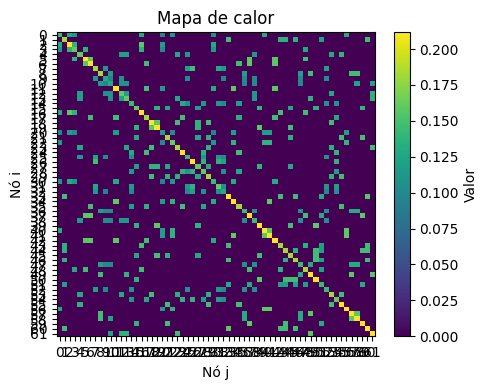

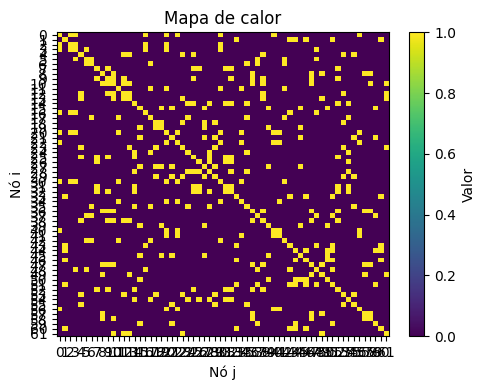

(<Figure size 500x400 with 2 Axes>,
 <Axes: title={'center': 'Mapa de calor'}, xlabel='Nó j', ylabel='Nó i'>)

In [28]:
plot_heatmap_nn(model.cell_0.current_adjacency(), figsize=(5,4))
plot_heatmap_nn(adjacency_matrix(N, edge_index), figsize=(5,4))

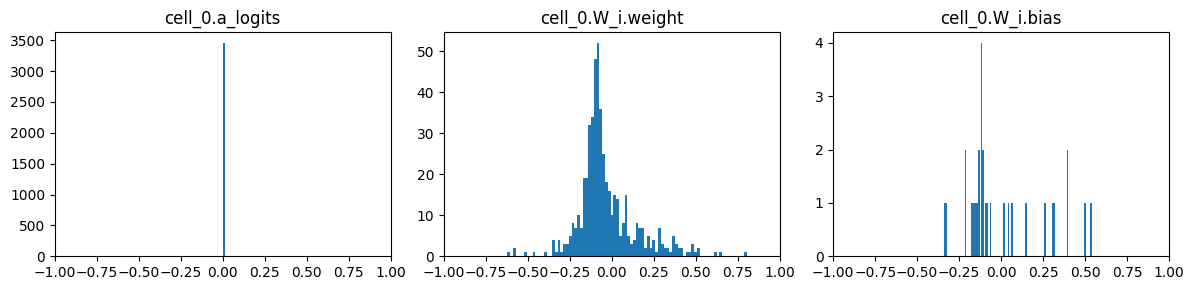

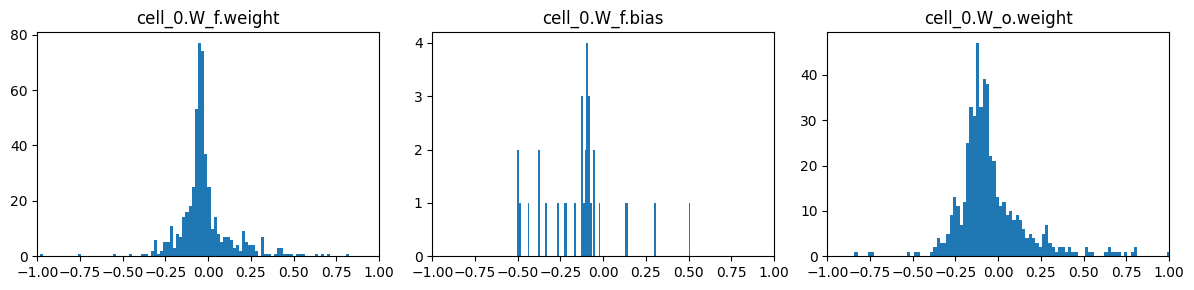

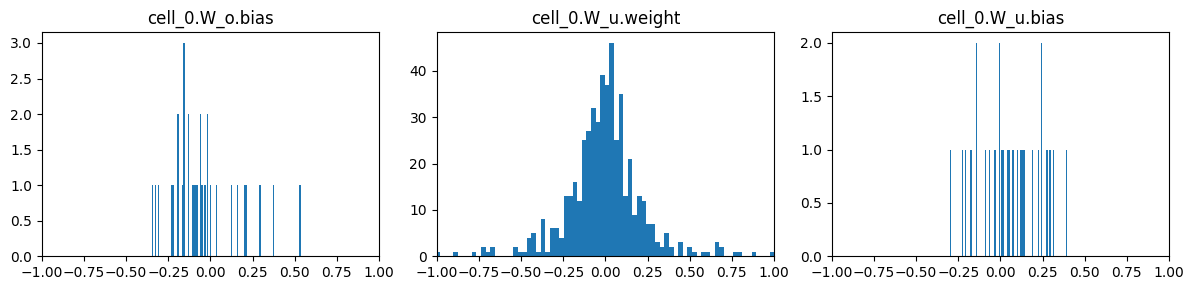

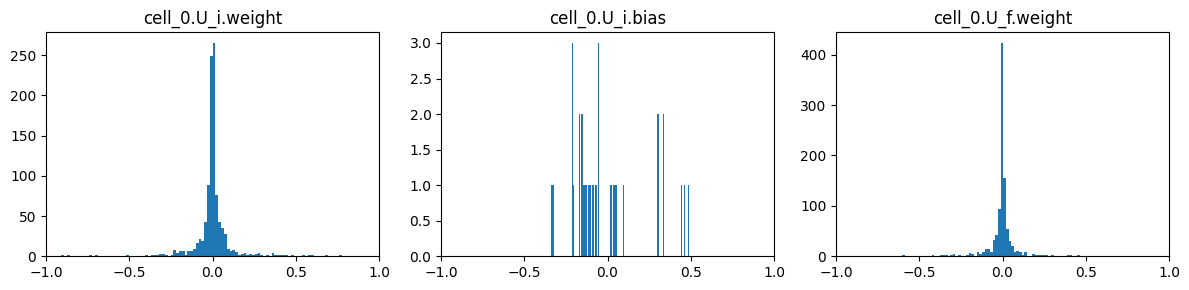

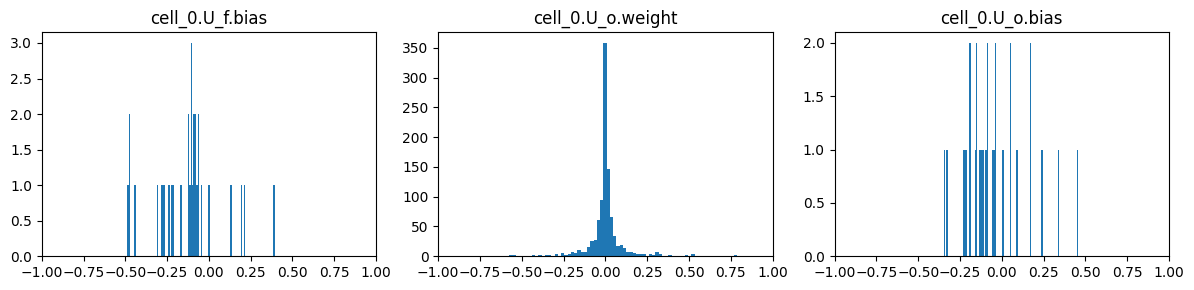

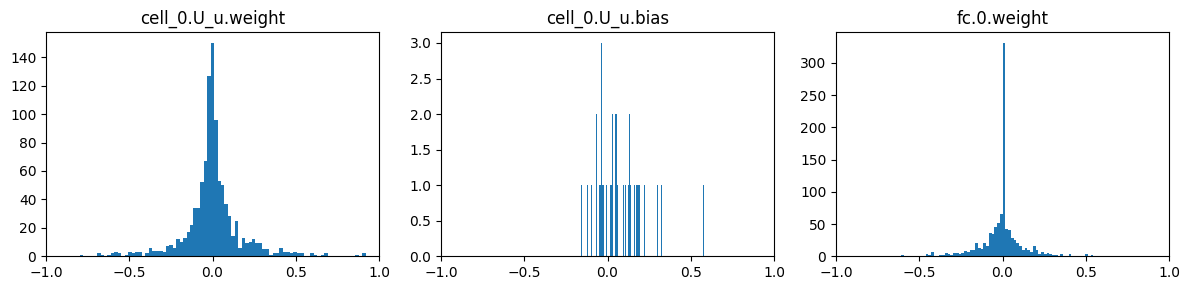

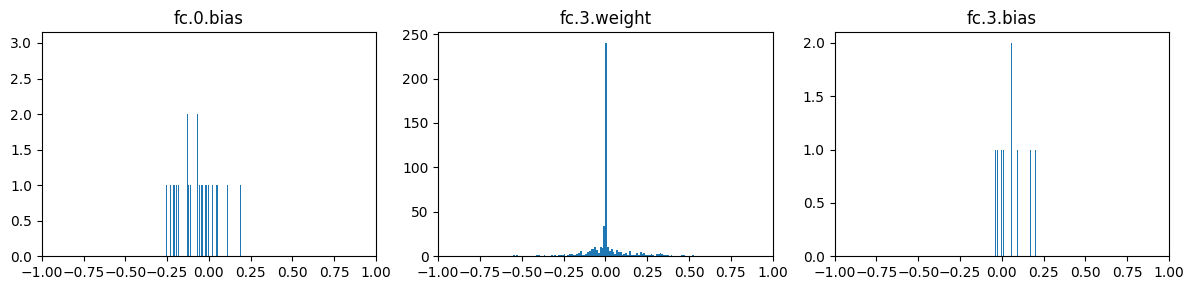

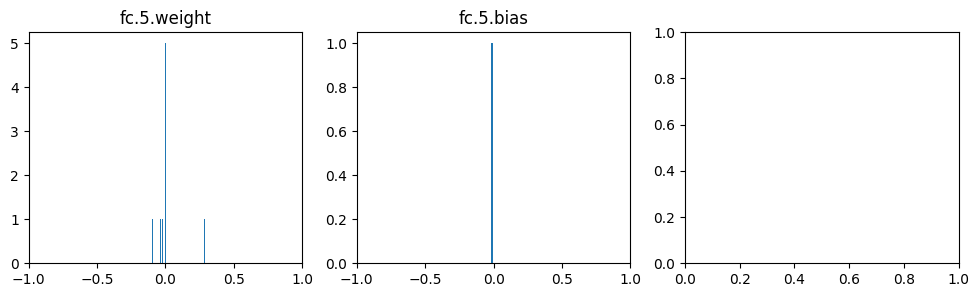

In [29]:
model_weights_hist(model)

# NEW STUFF



## CORRELATION TOPOLOGY FOR G




In [14]:
import numpy as np
import pandas as pd

def build_correlation_graph(X: np.ndarray, threshold: float = 0.5, ensure_connected: bool = True) -> np.ndarray:
    """
    Constrói matriz de adjacência baseada em correlação de Spearman
    entre séries temporais de precipitação.

    Args:
        X: tensor shape (dias, 62, 20)
        threshold: correlação mínima para criar aresta
        ensure_connected: garante que nós isolados tenham ao menos 1 aresta

    Returns:
        adj_matrix: np.ndarray shape (62, 62)
    """
    # Extrai precipitação: shape (dias, n_nos)
    precip = X[:, :, 0]  # (dias, 62)
    n_nos = precip.shape[1]

    # Correlação de Spearman entre todos os pares de estações
    # spearmanr retorna (correlação, pvalue) — pegamos só a matriz de corr
    from scipy.stats import spearmanr
    corr_matrix, _ = spearmanr(precip)  # (62, 62)
    corr_matrix = np.array(corr_matrix)

    # Aplica threshold
    adj_matrix = (corr_matrix >= threshold).astype(float)
    np.fill_diagonal(adj_matrix, 0)  # remove self-loops

    # Garante conectividade mínima
    if ensure_connected:
        degrees = adj_matrix.sum(axis=1)
        isolated = np.where(degrees == 0)[0]

        for node in isolated:
            # Conecta ao nó mais correlacionado (excluindo ele mesmo)
            corr_row = corr_matrix[node].copy()
            corr_row[node] = -999  # exclui self
            best = np.argmax(corr_row)
            adj_matrix[node, best] = 1
            adj_matrix[best, node] = 1  # mantém simetria

    return adj_matrix

Nós:          62
Arestas:      363
Grau médio:   11.71
Isolados:     0


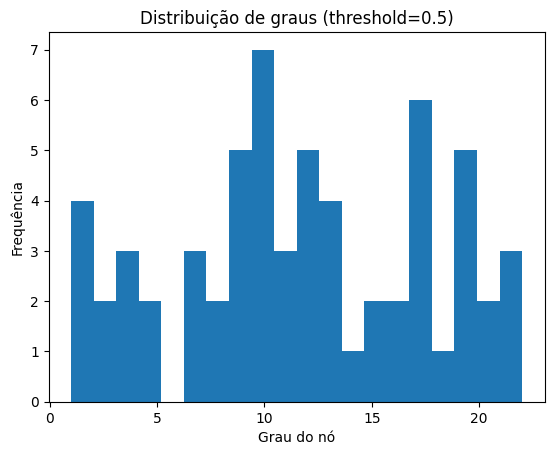

In [78]:
adj = build_correlation_graph(X, threshold=0.85)

# Diagnóstico rápido
n_nos = adj.shape[0]
n_arestas = int(adj.sum() / 2)
grau_medio = adj.sum(axis=1).mean()
isolados = (adj.sum(axis=1) == 0).sum()

print(f"Nós:          {n_nos}")
print(f"Arestas:      {n_arestas}")
print(f"Grau médio:   {grau_medio:.2f}")
print(f"Isolados:     {isolados}")

# Ver distribuição dos graus
import matplotlib.pyplot as plt
graus = adj.sum(axis=1)
plt.hist(graus, bins=20)
plt.xlabel("Grau do nó")
plt.ylabel("Frequência")
plt.title(f"Distribuição de graus (threshold={0.5})")
plt.show()

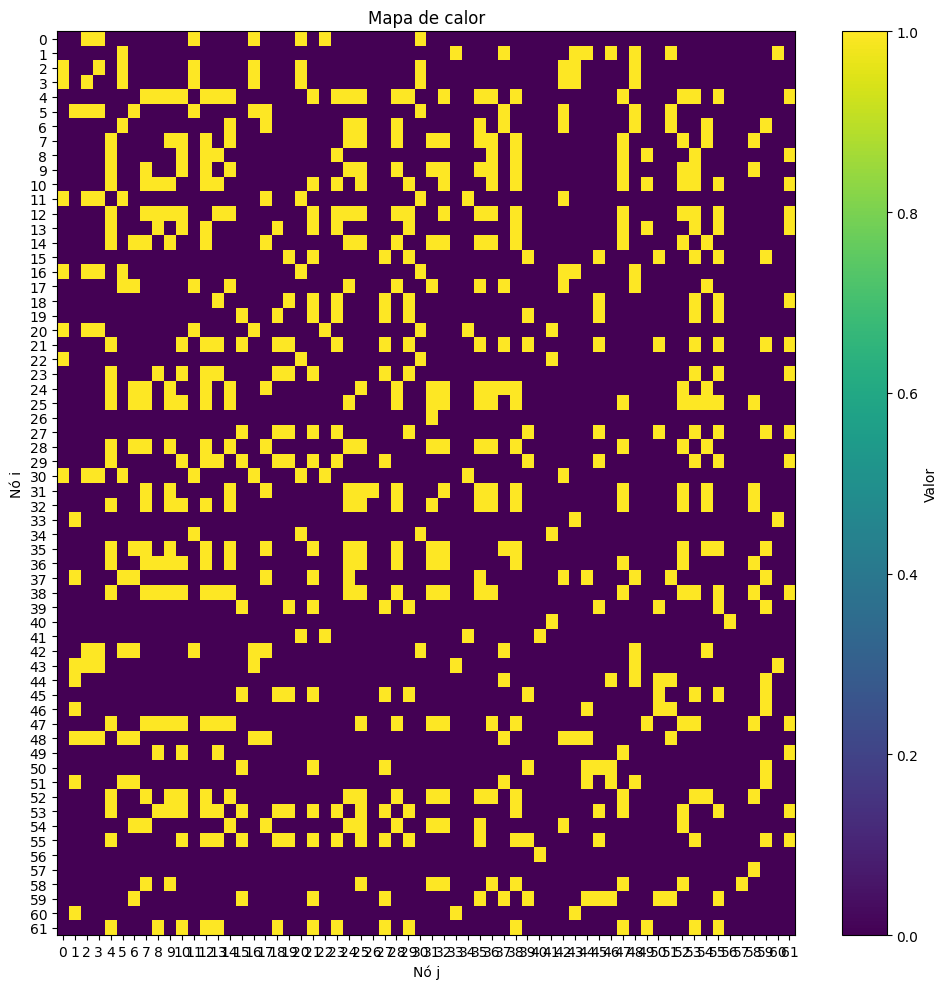

(<Figure size 1000x1000 with 2 Axes>,
 <Axes: title={'center': 'Mapa de calor'}, xlabel='Nó j', ylabel='Nó i'>)

In [ ]:
plot_heatmap_nn(adj)

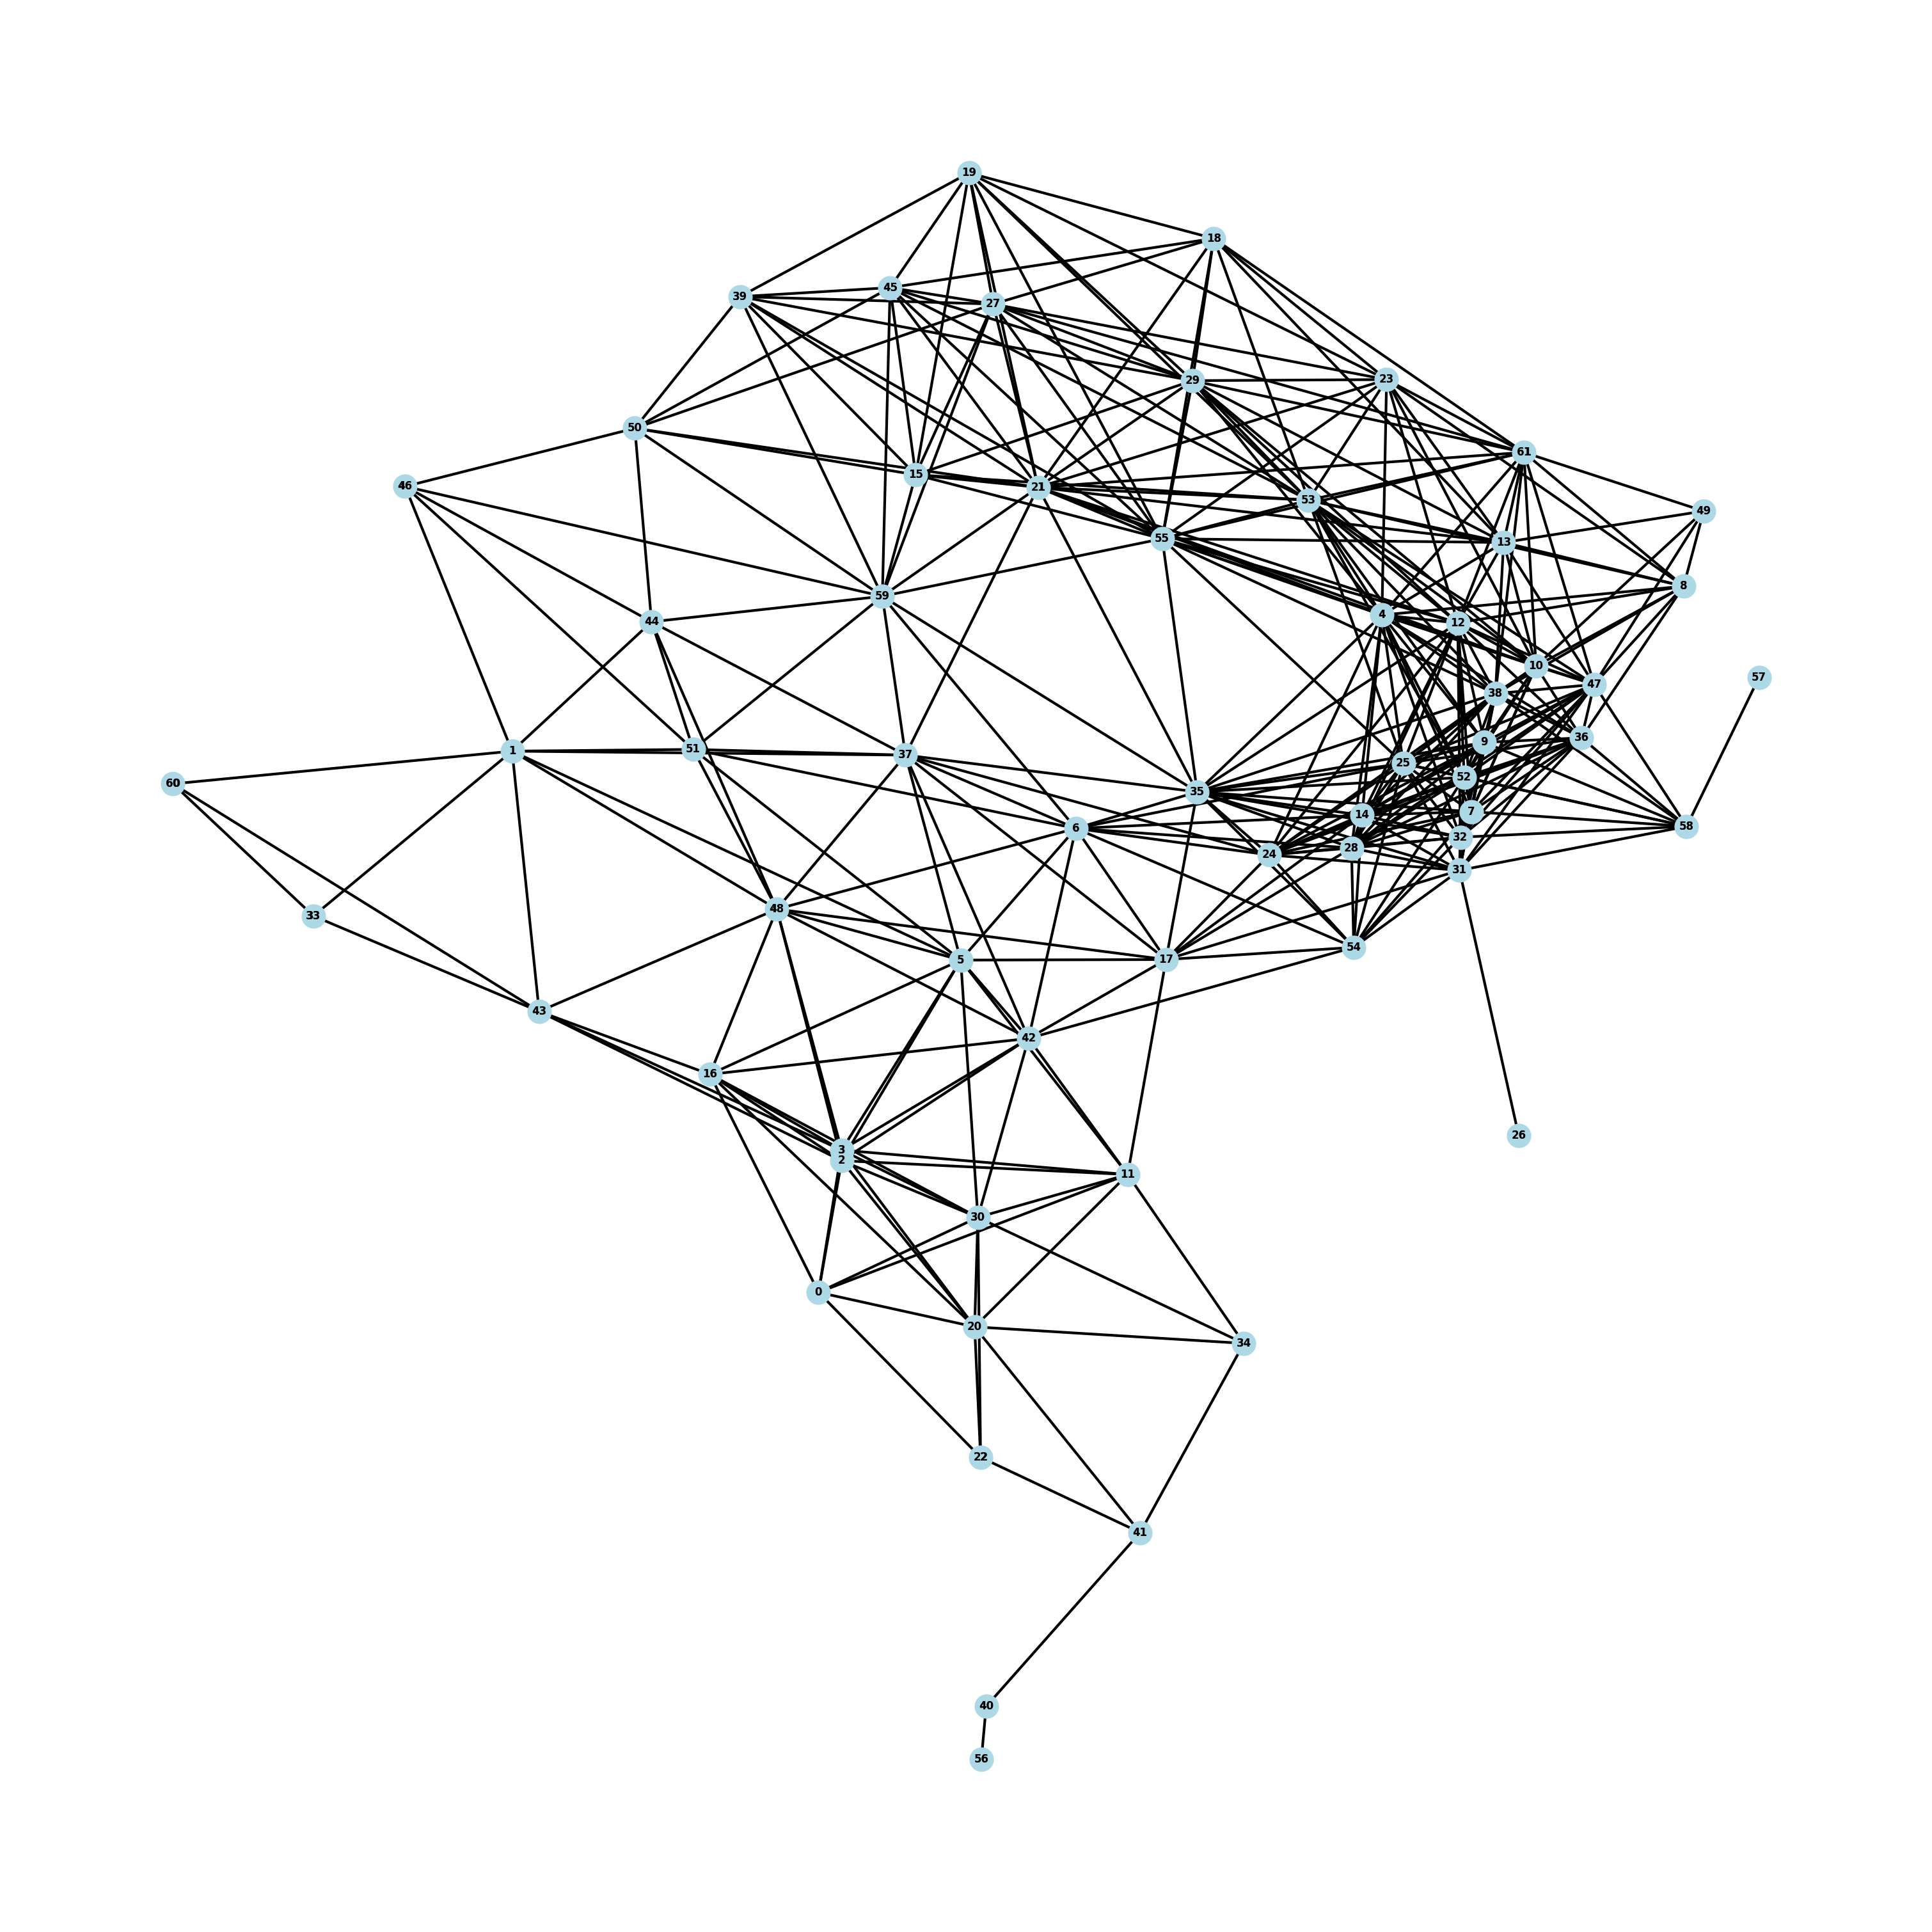

In [80]:
plot_graph(N, graph_matrix_index(torch.tensor(adj), threshold=0.5), pos)

## Weighted MSE Loss


In [19]:
def weighted_mse_loss_1(y_pred: torch.Tensor, y_true: torch.Tensor, 
                      threshold: float = 0.5, heavy_threshold: float = 15.0,
                      w_dry: float = 0.61, w_light: float = 1.0, w_heavy: float = 9546.28) -> torch.Tensor:
    """
    MSE ponderado por intensidade de precipitação.
    
    Pesos:
        - Dias secos  (precip < threshold)       → w_dry   (penaliza menos)
        - Chuva leve  (threshold <= precip < heavy_threshold) → w_light
        - Chuva forte (precip >= heavy_threshold) → w_heavy (penaliza mais)

    Args:
        y_pred:           predições do modelo
        y_true:           valores reais
        threshold:        limiar chuva/seco em mm (default 0.5mm)
        heavy_threshold:  limiar chuva forte em mm (default 15mm)
        w_dry:            peso dias secos
        w_light:          peso chuva leve
        w_heavy:          peso chuva forte

    Returns:
        loss escalar
    """
    # Máscara por categoria (baseada nos valores reais)
    dry   = (y_true <  threshold).float()
    light = ((y_true >= threshold) & (y_true < heavy_threshold)).float()
    heavy = (y_true >= heavy_threshold).float()

    # Mapa de pesos com mesma shape que y_true
    weights = w_dry * dry + w_light * light + w_heavy * heavy

    # MSE ponderado
    squared_error = (y_pred - y_true) ** 2
    loss = (weights * squared_error).mean()

    return loss

In [18]:
import numpy as np

def suggest_weights(precip: np.ndarray, 
                    threshold=0.5, 
                    heavy_threshold=15.0):
    """
    Sugere pesos inversamente proporcionais à frequência de cada classe.
    precip: array 1D com todos os valores de precipitação do treino
    """
    dry   = (precip <  threshold).sum() / precip.shape[0]
    light = ((precip >= threshold) & (precip < heavy_threshold)).sum() / precip.shape[0]
    heavy = (precip >= heavy_threshold).sum() / precip.shape[0]

    print(f"Dias secos:    {dry*100:.1f}%")
    print(f"Chuva leve:    {light*100:.1f}%")
    print(f"Chuva forte:   {heavy*100:.1f}%")

    # Peso inverso à frequência, normalizado para w_light = 1.0
    w_dry   = (1 / dry)   / (1 / light)
    w_heavy = (1 / heavy) / (1 / light)

    print(f"\nPesos sugeridos:")
    print(f"  w_dry   = {w_dry:.2f}")
    print(f"  w_light = 1.00")
    print(f"  w_heavy = {w_heavy:.2f}")

# Uso — precip de todos os nós e dias do treino
precip_train = X_train[..., 0].flatten()

suggest_weights(precip_train)

Dias secos:    84.6%
Chuva leve:    15.4%
Chuva forte:   0.0%

Pesos sugeridos:
  w_dry   = 0.18
  w_light = 1.00
  w_heavy = 9546.28
